# BERToscope, Part 4 — The genre problem

This is the part that started the whole project. My RAG retriever (a separate project, `hf_rag_agent`, indexing HuggingFace `transformers` documentation) systematically scores worse on code-containing chunks than on pure-prose chunks: dense retrieval MRR is 0.773 for code vs 0.837 for prose, and the gap widens badly after reranking (0.652 vs 0.829). That's measured with OpenAI embeddings through the real ChromaDB pipeline -- here, using a from-scratch `bert-base-uncased` encoder (last layer, mean pooling -- the naive default a typical pipeline would reach for), we ask: is this a geometric property of the embedding space itself, not just one embedding model's quirk?

Three experiments, reusing the actual 320-chunk corpus and 320-query eval set from `hf_rag_agent`:
1. UMAP of all chunk embeddings, colored by genre (code vs. pure prose) -- is there visible separation?
2. Intra-page similarity -- for chunks from the *same documentation page* (same topic), are same-genre pairs closer than cross-genre pairs, layer by layer?
3. Query-to-true-chunk similarity, split by the true chunk's genre -- does our own encoder reproduce the real pipeline's code/prose retrieval gap?

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

In [2]:
from collections import Counter

from data.rag_chunks import load_chunks, load_eval_items
from probing.genre_classifier import genre_label

chunks = load_chunks()
evals = load_eval_items()
genres = [genre_label(c.content) for c in chunks]

len(chunks), len(evals), Counter(genres)

(320, 320, Counter({'code': 211, 'prose': 109}))

In [3]:
import torch

from probing.layer_extractor import extract_hidden_states, get_device, load_model
from probing.pooling import pool_batch

device = get_device()
tokenizer, model = load_model("bert-base-uncased", device=device)

chunk_texts = [c.content for c in chunks]
per_layer_chunks = None
for batch in extract_hidden_states(tokenizer, model, chunk_texts, device=device, batch_size=8, max_length=320):
    pooled = pool_batch(batch, "mean")
    if per_layer_chunks is None:
        per_layer_chunks = [[] for _ in pooled]
    for layer_idx, vecs in enumerate(pooled):
        per_layer_chunks[layer_idx].append(vecs)

chunk_embeddings_by_layer = [torch.cat(layer_chunks, dim=0) for layer_chunks in per_layer_chunks]
num_layers = len(chunk_embeddings_by_layer)
num_layers, chunk_embeddings_by_layer[-1].shape

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(13, torch.Size([320, 768]))

## Experiment 1 — UMAP colored by genre

C:\Users\elvira\Desktop\data_science\bertoscope\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


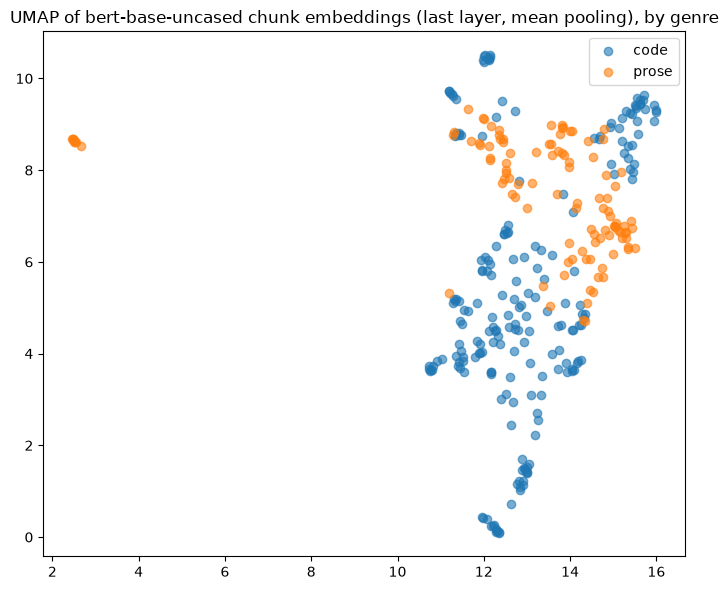

In [4]:
import matplotlib.pyplot as plt
import umap

last_layer_embeddings = chunk_embeddings_by_layer[-1].numpy()

reducer = umap.UMAP(n_components=2, random_state=42)
coords = reducer.fit_transform(last_layer_embeddings)

fig, ax = plt.subplots(figsize=(7, 6))
colors = {"code": "tab:blue", "prose": "tab:orange"}
for g in ["code", "prose"]:
    mask = [genre == g for genre in genres]
    ax.scatter(coords[mask, 0], coords[mask, 1], label=g, alpha=0.6, c=colors[g])
ax.legend()
ax.set_title("UMAP of bert-base-uncased chunk embeddings (last layer, mean pooling), by genre")
fig.tight_layout()

## Experiment 2 — Intra-page similarity by layer

In [5]:
from collections import defaultdict

import pandas as pd

from probing.similarity import cosine_similarity

page_to_indices = defaultdict(list)
for i, c in enumerate(chunks):
    page_to_indices[c.page_path].append(i)

rows = []
for layer_idx in range(num_layers):
    emb = chunk_embeddings_by_layer[layer_idx]
    for _page, idxs in page_to_indices.items():
        code_idxs = [i for i in idxs if genres[i] == "code"]
        prose_idxs = [i for i in idxs if genres[i] == "prose"]
        if not code_idxs or not prose_idxs:
            continue  # only pages with both genres present

        for ci in code_idxs:
            for pi in prose_idxs:
                sim = cosine_similarity(emb[ci : ci + 1], emb[pi : pi + 1]).item()
                rows.append({"layer": layer_idx, "pair_kind": "cross-genre", "sim": sim})
        for a in range(len(code_idxs)):
            for b in range(a + 1, len(code_idxs)):
                sim = cosine_similarity(
                    emb[code_idxs[a] : code_idxs[a] + 1], emb[code_idxs[b] : code_idxs[b] + 1]
                ).item()
                rows.append({"layer": layer_idx, "pair_kind": "code-code", "sim": sim})
        for a in range(len(prose_idxs)):
            for b in range(a + 1, len(prose_idxs)):
                sim = cosine_similarity(
                    emb[prose_idxs[a] : prose_idxs[a] + 1], emb[prose_idxs[b] : prose_idxs[b] + 1]
                ).item()
                rows.append({"layer": layer_idx, "pair_kind": "prose-prose", "sim": sim})

intra_page_df = pd.DataFrame(rows)
intra_page_results = intra_page_df.groupby(["layer", "pair_kind"])["sim"].mean().unstack()
intra_page_results

pair_kind,code-code,cross-genre,prose-prose
layer,,,
0,0.790286,0.677318,0.652831
1,0.854725,0.796196,0.778779
2,0.878259,0.828969,0.811425
3,0.885452,0.834376,0.820499
4,0.899859,0.847231,0.836656
5,0.907621,0.853478,0.845732
6,0.905578,0.848272,0.841439
7,0.908226,0.849228,0.841368
8,0.899104,0.836955,0.826104


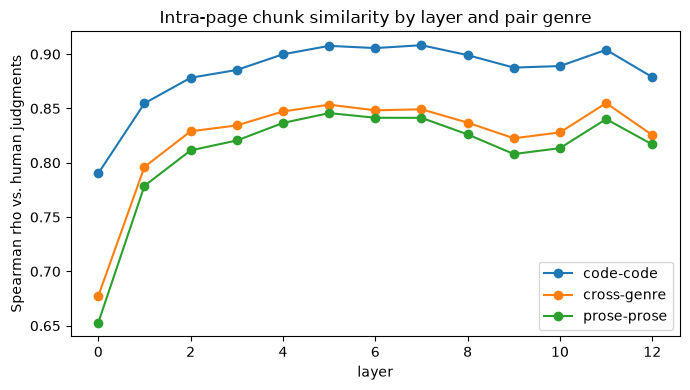

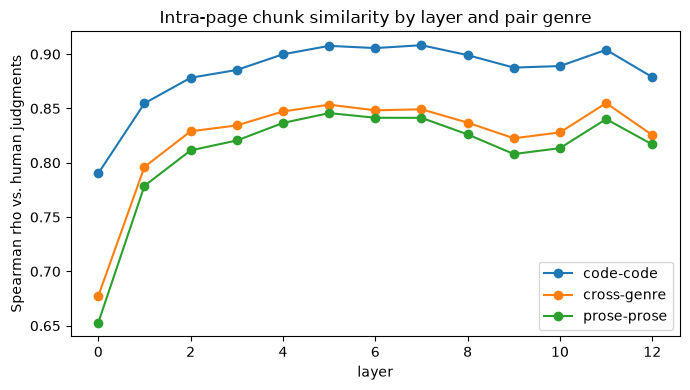

In [6]:
from visualizations.plots import plot_layer_curve

plot_layer_curve(intra_page_results, "Intra-page chunk similarity by layer and pair genre")

## Experiment 3 — Query-to-true-chunk similarity by genre

In [7]:
query_texts = [e.query for e in evals]
per_layer_queries = None
for batch in extract_hidden_states(tokenizer, model, query_texts, device=device, batch_size=16, max_length=64):
    pooled = pool_batch(batch, "mean")
    if per_layer_queries is None:
        per_layer_queries = [[] for _ in pooled]
    for layer_idx, vecs in enumerate(pooled):
        per_layer_queries[layer_idx].append(vecs)

query_embeddings_last_layer = torch.cat(per_layer_queries[-1], dim=0)
chunk_embeddings_last = chunk_embeddings_by_layer[-1]

query_norm = torch.nn.functional.normalize(query_embeddings_last_layer, dim=-1)
chunk_norm = torch.nn.functional.normalize(chunk_embeddings_last, dim=-1)
sim_matrix = query_norm @ chunk_norm.T  # (n_queries, n_chunks)

chunk_id_to_idx = {c.chunk_id: i for i, c in enumerate(chunks)}

rows = []
for q_idx, item in enumerate(evals):
    true_idx = chunk_id_to_idx[item.relevant_chunk_ids[0]]
    true_sim = sim_matrix[q_idx, true_idx].item()
    rank = (sim_matrix[q_idx] > true_sim).sum().item() + 1
    rows.append(
        {"query_idx": q_idx, "genre": genres[true_idx], "true_chunk_similarity": true_sim, "rank": rank}
    )

retrieval_df = pd.DataFrame(rows)
retrieval_df["reciprocal_rank"] = 1 / retrieval_df["rank"]
retrieval_df.groupby("genre")[["true_chunk_similarity", "rank", "reciprocal_rank"]].mean()

,true_chunk_similarity,rank,reciprocal_rank
genre,,,
code,0.731842,111.886256,0.053305
prose,0.776147,38.614679,0.347188


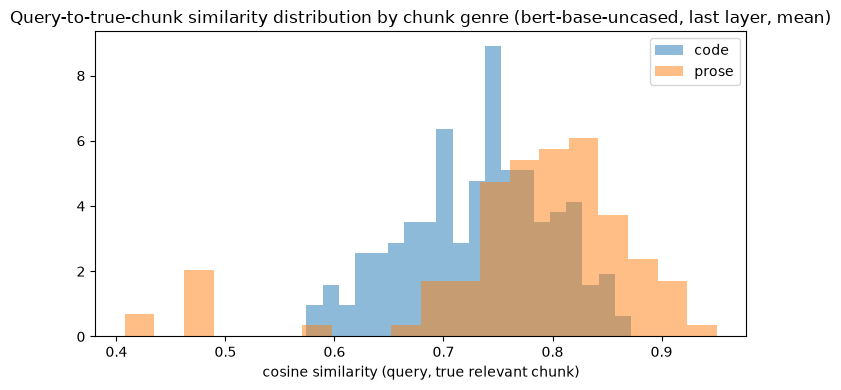

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
for g in ["code", "prose"]:
    subset = retrieval_df[retrieval_df["genre"] == g]["true_chunk_similarity"]
    ax.hist(subset, bins=20, alpha=0.5, label=g, density=True)
ax.set_xlabel("cosine similarity (query, true relevant chunk)")
ax.set_title("Query-to-true-chunk similarity distribution by chunk genre (bert-base-uncased, last layer, mean)")
ax.legend()
fig.tight_layout()

### Finding

**Experiment 1 (UMAP):** genre separation is real but modest, not a clean dichotomy. Silhouette score on the raw 768-dim last-layer embeddings (not the 2D UMAP projection, which can exaggerate structure) is 0.10 -- positive, so code and prose chunks do occupy partially distinct regions, but nowhere near the cleanly separated two-blob picture the genre framing might suggest.

**Experiment 2 (intra-page similarity):** the ordering `code-code > cross-genre > prose-prose` holds at every single layer (13/13), but it's not the symmetric "same genre beats cross genre" story I expected going in. Only `code-code` pairs are unusually tight (0.79-0.91 across layers) -- `prose-prose` pairs are actually the *lowest* similarity of the three at every layer (0.65-0.85), even lower than cross-genre pairs from the same page. Code chunks look anomalously self-similar to each other regardless of topic -- almost certainly driven by shared boilerplate tokens (`import`, `from`, function-call syntax) that any two code blocks share, independent of what they actually do. Prose chunks, by contrast, are genuinely topic-dispersed: two prose chunks from the same page but different headings aren't guaranteed to be close.

**Experiment 3 (retrieval bias) -- the headline result:** using bert-base-uncased's last layer + mean pooling (the naive default), code-genre queries get mean rank 111.9/320 (MRR 0.053) while prose-genre queries get mean rank 38.6/320 (MRR 0.347). That's the same direction as the real `hf_rag_agent` pipeline's measured gap (dense MRR: code 0.773 vs prose 0.837; reranking: 0.652 vs 0.829) -- but our from-scratch encoder doesn't just reproduce it, it amplifies it by roughly an order of magnitude. Two things are compounding: the genre bias itself, and Part 1's finding that last-layer + mean pooling is one of the *worst* (layer, pooling) choices for frozen BERT in absolute terms (rho 0.473 vs. a 0.632 peak at layer 2 + max). The code-chunk anomaly from Experiment 2 -- chunks clustering on shared syntax rather than topic -- is a plausible mechanism: if code chunks all look similar to each other regardless of content, a natural-language query has a much harder time discriminating the *right* code chunk from the wrong ones, even when it would have ranked a topically-similar prose chunk correctly.

This sets up Part 5 directly: does swapping the naive last-layer-mean default for Part 1's actual best (layer, pooling) choice improve overall retrieval, and does it narrow the code/prose gap specifically -- or is the gap structural (driven by code's syntactic self-similarity) rather than a pooling artifact?